<a target="_blank" href="https://colab.research.google.com/github/mrdbourke/learn-huggingface/blob/main/notebooks/hugging_face_llm_batched_inference_with_transformers.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

> **Note:** If you're running in Google Colab, make sure to enable GPU usage by going to Runtime -> Change runtime type -> select GPU.

[Source Code](https://github.com/mrdbourke/learn-huggingface/blob/main/notebooks/hugging_face_llm_batched_inference_with_transformers.ipynb) | [Markdown version](https://github.com/mrdbourke/learn-huggingface/blob/main/notebooks_md/hugging_face_llm_batched_inference_with_transformers.md) | [Slides](https://huggingface.co/datasets/mrdbourke/learn-hf-images/resolve/main/learn-hf-fine-tune-llm/learn-hf-fine-tune-llm-keynote-slides.pdf) | Video course (coming soon)


In [ ]:
import time

print(f"[INFO] Last updated: {time.ctime()}")

Last updated: Wed Apr 15 01:57:59 2026


## Overview

In the [Fine-tuning an LLM with Hugging Face Transformers Tutorial](https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial), we created [`FoodExtract-v1`](https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1), a Small Language Model (SLM) designed to extract food and drink items from raw text.

We saw our model can perform quite well on individual samples.

However, what if we wanted to run our model on a large batch of samples?

For example, let's say we wanted to filter a dataset of 1 billion rows of image captions such as [`Recap-DataComp-1B`](https://huggingface.co/datasets/UCSC-VLAA/Recap-DataComp-1B) for the food and drink related items, if we wanted to make 1 billion predictions, this might take quite a while.

**Batched inference** is a method to speed this up.

<figure style="text-align: center;">
    <!-- figtemplate -->
    <img src="https://huggingface.co/datasets/mrdbourke/learn-hf-images/resolve/main/learn-hf-fine-tune-llm/06-batch-inference-with-hf-transformers-overview.png"
     alt="
A diagram comparing 'One at a time inference' and 'Batched inference' using the 'Gemma 3' model. In the top row, four numbered samples are processed sequentially through the model one after another. In the bottom row, samples are grouped into vertical blocks of four, demonstrating how 'Batched inference' processes multiple inputs simultaneously to increase efficiency. A note at the bottom explains that while a batch size of 4 is shown, it can be customized based on 'hardware/model/data setup.'" 
     style="width: 100%; max-width: 900px; height: auto;"/>
     <figcaption>Batched inference helps to speed up inference by processing multiple samples at a time. If you need to perform inference across a large number of samples, batched inference is one of the best ways to speed things up.</figcaption>
</figure>

Batched inference allows us to make predictions on multiple samples at a time.

For example, we pass our model 16 samples at a time instead of 1.

Because our model is on the smaller side (270M parameters total), we can leverage our hardware's ability to run it multiple times in one go.

We can then zip together our model's outputs with the input samples and inspect them later on.

Our goal in this tutorial will be to perform batched inference on our dataset with Hugging Face Transformers.

::: {.callout-note}
This notebook is an extension of the [Fine-tuning an LLM with Hugging Face Transformers Tutorial](https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial).

Feel free to keep going through this notebook, however, if you'd like a background on the artifacts and how we trained our [`FoodExtract-v1`](https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1) model, be sure to go through the fine-tuning tutorial first.
:::

### Why perform batched inference?

The main goal of batched inference is for faster (higher throughput) predictions. Modern GPUs are often very good at parallelized computations. Therefore, predicting on multiple samples at a time is often much faster than one sample at a time.

Batched inference is often used in production workflows such as:

* Filtering a large dataset with a model.
* Replying to several users at a time with an LLM chat bot using the same model.

### Notes on batched inference

The number of samples you can predict on at once, known as the **batch size**, will depend on a few intertwined factors: 

* **The size of your model/available compute VRAM** - Model size and compute availability are intertwined. For example, your model has 7B parameters (~14GB memory footprint in float16 precision) but your GPU has 24GB of memory, your batch size might be limited to a lower number to account for memory bounds. Whereas, a model with a small number of parameters relative to the available GPU memory can often use a high batch size.
* **The size of your samples** - If one of your samples is 100x larger than other samples, this can negatively influence throughput. When performing batched inference, samples are often padded (bringing short sequences up to a certain length, often either the max length in a particular batch or a fixed value) or capped to be a certain size (for example, capping all sequences to a max of 512 total tokens, though this results in information loss). This uniformity of size (all tensors in the batch are the same size) takes advantage of GPU parallelism.

The optimal batch size for a particular hardware, model and data combination can be found experimentally.

To do so we can iterate through a number of different batches sizes and measure throughput speeds of each.

For example, we can experiment with batch sizes `1, 4, 8, 16, 32, 64, 128` (these are common values we can start with, powers of two are conventional starting points in the ML world and often work well in practice, however, our experiments are not bounded here, we could go larger or even choose a flat value like `100` if we wanted) and see which performs best.

:::{.callout-note}
A higher batch size generally results in a higher throughput of samples, however, this often levels out at a certain threshold.

For example, you might see a 4x speedup when going to batch size 16 (from batch size 1) but no speedup increases when going from batch size 16 to 64 (sometimes too large of a batch size can *degrade* performance).
:::

### Ingredients for batched inference

We'll need the following ingredients for our batched inference experiments:

* **Data** - Our target dataset will contain the samples we'll be performing batched inference on, we'll use the test samples from the [`FoodExtract-1k`](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k) dataset.
* **Model** - We'll use the [`FoodExtract-v1`](https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1) model (a fine-tuned version of Gemma 3 270M). 
* **Hardware** - This is flexible. For me, I could run this on my local NVIDIA DGX Spark or NVIDIA RTX 4090 GPU. However, it will also work well on GPUs provided by Google Colab. For more on running this locally, see the [setup guide](https://www.learnhuggingface.com/extras/setup).
* **Software** - For this notebook, we'll be using Hugging Face Transformers and its built-in offerings. For a future tutorial, we'd likely look into a dedicated inference engine such as [vLLM](https://github.com/vllm-project/vllm) or [SGLang](https://github.com/sgl-project/sglang). See the [*Inference with vLLM*](https://www.learnhuggingface.com/notebooks/hugging_face_llm_inference_with_vllm) notebook for more.

We'll start by downloading the target dataset and model and then we'll write the experimentation code for measuring batched inference speed.

## Loading a Dataset

Let's load in the dataset from the Hugging Face dataset ID [`mrdbourke/FoodExtract-1k`](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k).

The goal of this dataset is to train an LLM/SLM to extract food and drink items from a natural language input (see the [dataset card](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k) for more).

In [2]:
from datasets import load_dataset

DATASET_ID = "mrdbourke/FoodExtract-1k"

print(f"[INFO] Loading dataset: {DATASET_ID}")
dataset = load_dataset(DATASET_ID)

print(f"[INFO] Number of samples in the dataset: {len(dataset['train'])}")

[INFO] Loading dataset: mrdbourke/FoodExtract-1k
[INFO] Number of samples in the dataset: 1420


Now let's inspect a random sample.

In [3]:
import random

random_sample = random.choice(dataset['train'])
random_sample

{'sequence': '8 tier, all white wedding cake with hand piped detailing and ruffles all white wedding, hand pipes, romantic weddings, cake art, person, ruffles, wedding cakes, photos, beautiful',
 'image_url': 'https://i.pinimg.com/originals/e2/b7/21/e2b721e1eda8715091e5f85042d97888.jpg',
 'class_label': 'food',
 'source': 'qwen2vl_open_dataset',
 'char_len': 178.0,
 'word_count': 27.0,
 'syn_or_real': 'real',
 'uuid': '257e221d-c6be-4127-91ec-ba338dd0dd97',
 'gpt-oss-120b-label': "{'is_food_or_drink': True, 'tags': ['fi', 'fa'], 'food_items': ['wedding cake', 'cake', 'wedding cakes'], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 1\ntags: fi, fa\nfoods: wedding cake, cake, wedding cakes\ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None}

The model we trained in the [Fine-tuning an LLM Tutorial](https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial) wants to produce the output in the `"gpt-oss-120b-label-condensed"` field given the `"sequence"` field.

In [4]:
print(f"[INFO] Model input:\n{random_sample['sequence']}\n")
print(f"[INFO] Ideal model output:\n{random_sample['gpt-oss-120b-label-condensed']}")

[INFO] Model input:
8 tier, all white wedding cake with hand piped detailing and ruffles all white wedding, hand pipes, romantic weddings, cake art, person, ruffles, wedding cakes, photos, beautiful

[INFO] Ideal model output:
food_or_drink: 1
tags: fi, fa
foods: wedding cake, cake, wedding cakes
drinks:


### Turning sequences into prompt and completion pairs

Our model wants inputs in prompt and completion pairs in chat dictionary style.

Let's create a simple helper function to prepare these pairs.

In [5]:
# Create helper function to turn samples into prompt and completion pairs
def sample_to_prompt_completion(sample):
    """Helper function to convert an input sample to prompt-completion style."""
    return {
        "prompt": [
            {"role": "user", "content": sample["sequence"]}, # load the sequence from the dataset
        ],
        "completion": [
            {"role": "assistant", "content": sample["gpt-oss-120b-label-condensed"]} # load the condensed label from the ground truth
        ]
    }

sample_to_prompt_completion(random_sample)

{'prompt': [{'role': 'user',
   'content': '8 tier, all white wedding cake with hand piped detailing and ruffles all white wedding, hand pipes, romantic weddings, cake art, person, ruffles, wedding cakes, photos, beautiful'}],
 'completion': [{'role': 'assistant',
   'content': 'food_or_drink: 1\ntags: fi, fa\nfoods: wedding cake, cake, wedding cakes\ndrinks:'}]}

Wonderful!

Now let's map the `sample_to_prompt_completion` helper function to our dataset.

In [6]:
# Map the helper function to the dataset
dataset = dataset.map(sample_to_prompt_completion,
                      batched=False)

dataset["train"][42]

{'sequence': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
 'image_url': 'https://portforward.com/games/walkthroughs/The-Legend-of-Zelda-The-Wind-Waker/The-Legend-of-Zelda-The-Wind-Waker-large-430.jpg',
 'class_label': 'not_food',
 'source': 'qwen2vl_open_dataset',
 'char_len': 156.0,
 'word_count': 28.0,
 'syn_or_real': 'real',
 'uuid': 'bbac79ce-df1f-48b8-891c-752809be11c7',
 'gpt-oss-120b-label': "{'is_food_or_drink': 'false', 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'content': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
   'role': 'use

### Splitting our dataset into train and test splits

Our model has been trained on a portion of our dataset (specifically 80% of a random split with `seed=42`).

We want to test batched inference on the test portion of our dataset.

So we'll split our dataset using the same split we originally used for model training.

In [7]:
# Create a train/test split
dataset = dataset["train"].train_test_split(test_size=0.2, 
                                            shuffle=False,
                                            seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 1136
    })
    test: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 284
    })
})

Now we can assign the test dataset to its own variable.

In [8]:
test_dataset = dataset["test"]
print(f"[INFO] Number of samples in the test dataset: {len(test_dataset)}")

[INFO] Number of samples in the test dataset: 284


## Loading the model and tokenizer

Our fine-tuned model is hosted on Hugging Face under the model ID [`mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1`](https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1) (yours may be under your own username).

Let's load it in as well as its tokenizer so we can make predictions with it.

In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1"

print(f"[INFO] Loading tokenizer and model from: {MODEL_ID}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=MODEL_ID)

# Load model
model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=MODEL_ID,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)

print(f"[INFO] Tokenizer and model loaded from: {MODEL_ID}")

# Check our model
model

[INFO] Loading tokenizer and model from: mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1


/home/mrdbourke/miniforge3/envs/ai/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


[INFO] Tokenizer and model loaded from: mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1


Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 640, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=640, out_features=1024, bias=False)
          (k_proj): Linear(in_features=640, out_features=256, bias=False)
          (v_proj): Linear(in_features=640, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=640, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=640, out_features=2048, bias=False)
          (up_proj): Linear(in_features=640, out_features=2048, bias=False)
          (down_proj): Linear(in_features=2048, out_features=640, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma3RMSNorm((640,), eps=1e-06)

Excellent!

We can see our model uses the Gemma 3 270M architecture.

Let's now turn it into a `transformers.pipeline` with `task="text-generation"` so we can easily try it out.

In [10]:
# Turn our loaded model into a pipeline for easy handling of preprocessing
from transformers import pipeline

loaded_model_pipeline = pipeline(task="text-generation",
                                 model=model,
                                 tokenizer=tokenizer)

loaded_model_pipeline

Device set to use cuda:0


## Formatting our dataset with the chat template

By default, our model comes with an assumed chat template for inputs.

Let's assign that chat template to every sample in the test dataset.

To do so, we'll add an extra column called `"formatted_prompt"`.

In [44]:
from pprint import pprint

def format_input_prompt(sample):
    """Helper function to add the tokenizer chat template to the input prompt."""
    formatted_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(sample["prompt"],
                                                                           tokenize=False,
                                                                           add_generation_prompt=True)
    return {"formatted_prompt": formatted_prompt}

print(f"[INFO] Input prompt (prior to formatting with chat template):\n\n{test_dataset[7]['prompt'][0]['content']}\n")
print(f"[INFO] Input prompt (after formatting with chat template):\n\n{format_input_prompt(test_dataset[7])}\n")

[INFO] Input prompt (prior to formatting with chat template):

A jar of Hum Honey is held in a hand, displaying a label that reads "CONTAINS POLLEN WHICH CAN CAUSE SEVERE ALLERGIC REACTIONS." The ingredients are listed as "Australian Honey," and the product is noted as "Not Microfiltered. 100% Australian Owned and Family Operated." The label includes storage instructions: "STORE AT ROOM TEMPERATURE IN A DRY COOL PLACE OR IN THE REFRIGERATOR FOR A FIRM TEXTURE." The address "HUM HONEY 323 RIVER ROAD PEACHESTER QLD 4519" is also visible. The nutrition information panel shows a serving size of 15g with 20 servings per package. Nutritional values include 210 kJ energy, 0g protein, 0g fat, 12.3g carbohydrates, and 2mg sodium per serving. The label also features a recycling symbol and an Australian Honey logo. A batch number "08012535" is attached to the jar.

[INFO] Input prompt (after formatting with chat template):

{'formatted_prompt': '<bos><start_of_turn>user\nA jar of Hum Honey is hel

Excellent, now we've got a quick way to access a target sequence with the chat template applied.

Let's apply the `format_input_prompt` to the whole test dataset. 

In [12]:
# Format the test dataset with the prompt template
test_dataset = test_dataset.map(format_input_prompt, batched=False)
test_dataset[42]

Map:   0%|          | 0/284 [00:00<?, ? examples/s]

{'sequence': "This image shows the back of a food package with detailed cooking instructions, ingredients, and nutrition information. The package is held in a person's hand, and the background includes a concrete floor and part of a shoe.\n\n**Cooking Instructions:**\n- Ingredients listed include 1 cup snow peas, 1/2 cup frozen edamame, 2 cloves garlic, 2cm piece ginger, 1/4 cup stock of choice, 180g udon noodles, 3 spring onions, and 2 tablespoons sesame seeds.\n- Instructions mention cooking snow peas and edamame, adding oil, garlic, ginger, and stock, and then adding cooked udon noodles and tossing with protein, sesame seeds, and spring onions.\n\n**Nutrition Information:**\n- Servings per pack: 4\n- Serving size: 44g\n- Energy: 88kJ (21kcal) per serve, 201kJ (48kcal) per 100g\n- Protein: 0.4g per serve, 0.9g per 100g\n- Fat, Total: 0.6g per serve, 1.4g per 100g\n- Saturated Fat: 0.1g per serve, 0.3g per 100g\n- Carbohydrate: 3.4g per serve, 7.8g per 100g\n- Sugars: 1.1g per serve, 

## Trying our model on an example sample from the test dataset

Before we do batched inference, let's ensure inference works on a single sample.

Since we've already add the `"formatted_prompt"` column, we can easily perform inference by passing it to our `loaded_model_pipeline`.

We'll time how long inference takes as well so we can an idea of what we're looking at for a single sample.

In [13]:
import time

# Pick a random sample from the test dataset
random_test_sample = random.choice(test_dataset)  

# Run the model on the random sample
start_time = time.time()
random_sample_generated_output = loaded_model_pipeline(random_test_sample["formatted_prompt"],
                                                       max_new_tokens=256,
                                                       disable_compile=True,
                                                       return_full_text=False) # only return the generated text, not the full prompt + generated
end_time = time.time()
total_time = round(end_time - start_time, 3)

print(f"[INFO] Random test set sample input:\n{random_test_sample['prompt']}\n")
print(f"[INFO] Random test set sample formatted with chat template input:\n{random_test_sample['formatted_prompt']}")
print(f"[INFO] Random test sample ground truth:\n{random_test_sample['gpt-oss-120b-label-condensed']}\n")
print(f"[INFO] Model generated output:\n{random_sample_generated_output[0]['generated_text']}\n")
print(f"[INFO] Time taken: {total_time}s")

[INFO] Random test set sample input:
[{'content': 'emb!ptYmT?)C*]*=x{l"\\=3{H\'HZ9zP4HqsAB_tsu|$c>n:LG', 'role': 'user'}]

[INFO] Random test set sample formatted with chat template input:
<bos><start_of_turn>user
emb!ptYmT?)C*]*=x{l"\=3{H'HZ9zP4HqsAB_tsu|$c>n:LG<end_of_turn>
<start_of_turn>model

[INFO] Random test sample ground truth:
food_or_drink: 0
tags: 
foods: 
drinks:

[INFO] Model generated output:
food_or_drink: 0
tags: 
foods: 
drinks:

[INFO] Time taken: 0.792s


Nice!

Looks like for longer prompts we get around 1-2s of inference time and for shorter prompts we get 0.1-0.5s of inference time (note: this was measured on my NVIDIA DGX Spark and will be different depending on the hardware you use).

## Running batched inference three different ways

To get familiar with running batched inference using Hugging Face Transformers, we'll set it up to run three different ways across a number of batch sizes.

Each option results in the same outputs but goes about it in a slightly different way.

| Number | Option | Description | Setup Difficulty |
| ----- | ----- | ----- | ----- |
| 1 | Manual batching | We create the batches ourselves with code and can customize them how we like. This offers full control on the batching pipeline but is exposed to potential errors if not setup correctly. | Medium | 
| 2 | [`pipeline`](https://huggingface.co/docs/transformers/en/main_classes/pipelines#transformers.pipeline) batching | Built in to `transformers.pipeline`. Offers a simple setup, however, the tradeoff is less control during inference. Requires the input to be materialized to a list (this can cause memory issues for large datasets). | Easy |
| 3 | `KeyDataset` batching | Works by creating batches directly on a Hugging Face Dataset instance by referencing to PyTorch's Dataset object on the fly. You pick a "key" of the target dataset and the batch will be created from that key. Is robust for larger datasets. | Medium | 

Which one you choose will depend on your use case.

The good news is, after being hands on with them all, you'll have a good idea which is best for you.

### Option 1: Running batched inference with manual batching

We'll start by manually creating batches of various sizes and then performing inference on them.

To do so, let's extract indices of certain batch sizes from the `test_dataset` with [`datasets.Dataset.select`](https://huggingface.co/docs/datasets/en/package_reference/main_classes#datasets.Dataset.select).

We'll time each of the inference steps and save it to a results dictionary so we can inspect them later on.

In [14]:
import time 
from tqdm.auto import tqdm

all_outputs_manual = {}

BATCH_SIZES_TO_TEST = [1, 4, 8, 16, 32, 64, 128] # customize these based on the size of your model and GPU memory
VERBOSE = False

# Loop through batch sizes
for BATCH_SIZE in BATCH_SIZES_TO_TEST:
    print(f"\n[INFO] Running inference with batch size: {BATCH_SIZE}")
    start_time = time.time()
    
    # Loop through the test dataset and perform inference on the chosen batch size
    batched_outputs_list = []
    for batch_num in tqdm(range(round(len(test_dataset) / BATCH_SIZE)), desc=f"Batch size {BATCH_SIZE}"):

        # Calculate the target index numbers of the dataset to select for the current batch
        # Add a check to ensure we don't go out of bound of the dataset length
        idxs_to_select = [i for i in list(range(BATCH_SIZE * batch_num, BATCH_SIZE * (batch_num + 1))) if i < len(test_dataset)]
        if VERBOSE:
            print(f"[INFO] Working on indexes: {idxs_to_select}")

        # Select indexes from the dataset and extract the formatted prompts for the current batch
        # Note: .select() expects a list of indicies to for indexing (e.g. [0, 1, 2, 3, 4, 5])
        batched_inputs = test_dataset.select(idxs_to_select)
        batched_formatted_prompts = [item["formatted_prompt"] for item in batched_inputs]

        # Perform inference with pipeline on a list of input prompts and store the outputs
        batched_outputs = loaded_model_pipeline(batched_formatted_prompts,
                                                batch_size=BATCH_SIZE,
                                                max_new_tokens=256,
                                                disable_compile=True,
                                                return_full_text=False) # only return the generated text, not the full prompt + generated text
        
        # Add the outputs for the current batch to the list of inputs (so we can compare the generated outputs with the inputs later on if we want)
        batched_inputs_list = list(batched_inputs)
        for i in range(len(batched_outputs)):
            batched_inputs_list[i]["generated_text"] = batched_outputs[i][0]["generated_text"]

        # Extend the list of outputs
        batched_outputs_list.extend(batched_inputs_list)
    
    # End timer and save it to dictionary
    end_time = time.time()
    total_time = end_time - start_time
    avg_time_per_sample = total_time / len(test_dataset)

    # Append the outputs and total time for the current batch to our results dictionary
    all_outputs_manual[BATCH_SIZE] = {"batched_outputs_list": batched_outputs_list, 
                                      "total_time": total_time,
                                      "avg_time_per_sample": avg_time_per_sample}

    print(f"[INFO] Total inference time for batch size {BATCH_SIZE}: {total_time:.2f} seconds")
    print(f"[INFO] Average inference time per sample for batch size {BATCH_SIZE}: {avg_time_per_sample:.2f} seconds")
    print("="*80)


[INFO] Running inference with batch size: 1


Batch size 1:   0%|          | 0/284 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[INFO] Total inference time for batch size 1: 142.38 seconds
[INFO] Average inference time per sample for batch size 1: 0.50 seconds

[INFO] Running inference with batch size: 4


Batch size 4:   0%|          | 0/71 [00:00<?, ?it/s]

...

[INFO] Total inference time for batch size 32: 24.41 seconds
[INFO] Average inference time per sample for batch size 32: 0.09 seconds

[INFO] Running inference with batch size: 64


Batch size 64:   0%|          | 0/4 [00:00<?, ?it/s]

[INFO] Total inference time for batch size 64: 31.50 seconds
[INFO] Average inference time per sample for batch size 64: 0.11 seconds

[INFO] Running inference with batch size: 128


Batch size 128:   0%|          | 0/2 [00:00<?, ?it/s]

[INFO] Total inference time for batch size 128: 48.37 seconds
[INFO] Average inference time per sample for batch size 128: 0.17 seconds


Batched inference complete! 

Notice how the inference times started to go down after the batch sizes started to increase?

But they didn't continually go down, they levelled off at a certain point.

This is likely the GPU getting saturated with enough samples to take advantage of the hardware so adding more didn't improve throughput.

Let's inspect the sizes as well as total inference times and average time per sample.

In [15]:
print(f"[INFO] Showing information for manually created batched input inference:")
for key, value in all_outputs_manual.items():
    print(f"Batch size: {key} | Total inference time: {value['total_time']:.2f} seconds | Total samples: {len(value['batched_outputs_list'])} | Average time per sample: {value['avg_time_per_sample']:.2f} seconds")

[INFO] Showing information for manually created batched input inference:
Batch size: 1 | Total inference time: 142.38 seconds | Total samples: 284 | Average time per sample: 0.50 seconds
Batch size: 4 | Total inference time: 53.14 seconds | Total samples: 284 | Average time per sample: 0.19 seconds
Batch size: 8 | Total inference time: 31.27 seconds | Total samples: 284 | Average time per sample: 0.11 seconds
Batch size: 16 | Total inference time: 28.72 seconds | Total samples: 284 | Average time per sample: 0.10 seconds
Batch size: 32 | Total inference time: 24.41 seconds | Total samples: 284 | Average time per sample: 0.09 seconds
Batch size: 64 | Total inference time: 31.50 seconds | Total samples: 256 | Average time per sample: 0.11 seconds
Batch size: 128 | Total inference time: 48.37 seconds | Total samples: 256 | Average time per sample: 0.17 seconds


Which batch size performed best for you on your hardware?

::: {.callout-note}
If your numbers aren't the exact same as mine here, don't worry.

They will vary depending on the hardware you're using (the same goes for different models and datasets).

For example, if you're running the model on a small local GPU, inference will likely be slower than if you were running on a larger cloud-based GPU.
:::

### Option 2: Running batched inference with automatic batching using pipeline

As we saw above, the `transformers.pipeline` class offers in-built batching via the `batch_size` parameter.

However, to take advantage of this we need to turn all of our input samples into a materialized list.

This means for quite a large dataset we might run into memory issues.

As before, we'll save all of the results to a dictionary which we can easily inspect.

In [16]:
import time

# Create outputs storage
all_outputs_pipeline = {}

BATCH_SIZES_TO_TEST = [1, 4, 8, 16, 32, 64, 128] # customize these based on the size of your model and GPU memory
VERBOSE = False

# Turn our input prompts into a list for the pipeline
test_input_prompts = list(test_dataset["formatted_prompt"])
print(f"[INFO] Total number of samples to run through the pipeline: {len(test_input_prompts)}")

for BATCH_SIZE in BATCH_SIZES_TO_TEST:
    print(f"[INFO] Running inference with batch size: {BATCH_SIZE}")
    start_time = time.time()

    # Use transformers in-built pipeline batching
    pipeline_outputs = loaded_model_pipeline(
        text_inputs=test_input_prompts,
        batch_size=BATCH_SIZE,
        max_new_tokens=256,
        return_full_text=False
    )
    print(f"[INFO] Total pipeline outputs: {len(pipeline_outputs)}")

    # Save all the timing metrics
    end_time = time.time()
    total_time = end_time - start_time
    avg_time_per_sample = total_time / len(test_input_prompts)
    
    # Zip together outputs and inputs
    # pipeline_outputs is a list of dictionaries in the form [{"generated_text": "..."}, ...]
    batched_outputs_list = list(test_dataset)
    for i in range(len(test_input_prompts)):
        batched_outputs_list[i]["generated_text"] = pipeline_outputs[i][0]["generated_text"]

    # Make a check that the output is the same length as the test dataset
    assert len(batched_outputs_list) == len(test_dataset), f"Lengths of batched_output_list (len={len(batched_outputs_list)}) and test_dataset (len={len(test_dataset)}) don't line up"

    # Output statement of how we're going
    print(f"[INFO] Total inference time for batch size {BATCH_SIZE}: {total_time:.2f} seconds")
    print(f"[INFO] Average inference time per sample for batch size {BATCH_SIZE}: {avg_time_per_sample:.2f} seconds")
    print("="*80 + "\n\n")

    # Append results to the dictionary
    all_outputs_pipeline[BATCH_SIZE] = {"batched_outputs_list": batched_outputs_list, 
                                        "total_time": total_time,
                                        "avg_time_per_sample": avg_time_per_sample}

[INFO] Total number of samples to run through the pipeline: 284
[INFO] Running inference with batch size: 1
[INFO] Total pipeline outputs: 284
[INFO] Total inference time for batch size 1: 143.15 seconds
[INFO] Average inference time per sample for batch size 1: 0.50 seconds


[INFO] Running inference with batch size: 4
[INFO] Total pipeline outputs: 284
[INFO] Total inference time for batch size 4: 53.93 seconds
[INFO] Average inference time per sample for batch size 4: 0.19 seconds


[INFO] Running inference with batch size: 8
[INFO] Total pipeline outputs: 284
[INFO] Total inference time for batch size 8: 37.82 seconds
[INFO] Average inference time per sample for batch size 8: 0.13 seconds


[INFO] Running inference with batch size: 16
[INFO] Total pipeline outputs: 284
[INFO] Total inference time for batch size 16: 26.10 seconds
[INFO] Average inference time per sample for batch size 16: 0.09 seconds


[INFO] Running inference with batch size: 32
[INFO] Total pipeline outputs: 284


In [17]:
print(f"[INFO] Showing information for transformers.pipeline default batched input inference:")
for key, value in all_outputs_pipeline.items():
    print(f"Batch size: {key} | Total inference time: {value['total_time']:.2f} seconds | Total samples: {len(value['batched_outputs_list'])} | Average time per sample: {value['avg_time_per_sample']:.2f} seconds")

[INFO] Showing information for transformers.pipeline default batched input inference:
Batch size: 1 | Total inference time: 143.15 seconds | Total samples: 284 | Average time per sample: 0.50 seconds
Batch size: 4 | Total inference time: 53.93 seconds | Total samples: 284 | Average time per sample: 0.19 seconds
Batch size: 8 | Total inference time: 37.82 seconds | Total samples: 284 | Average time per sample: 0.13 seconds
Batch size: 16 | Total inference time: 26.10 seconds | Total samples: 284 | Average time per sample: 0.09 seconds
Batch size: 32 | Total inference time: 26.91 seconds | Total samples: 284 | Average time per sample: 0.09 seconds
Batch size: 64 | Total inference time: 26.41 seconds | Total samples: 284 | Average time per sample: 0.09 seconds
Batch size: 128 | Total inference time: 40.15 seconds | Total samples: 284 | Average time per sample: 0.14 seconds


### Option 3: Running batched inference with a KeyDataset

Using a [`transformers.pipelines.pt_utils.KeyDataset`](https://huggingface.co/docs/transformers/main_classes/pipelines#pipeline-batching) (`KeyDataset` for short) offers us the benefits of [PyTorch's Dataset](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html) behind the scenes and is great for working with larger datasets.

It enables us to *not* have to turn our whole dataset into a list to iterate over it. 

We can lazily load batches of samples when we need to.

The `KeyDataset` object works on the premise of us passing it a target `Dataset` and a target `key`.

For example, `KeyDataset(dataset=test_dataset, key="formatted_prompt")`, in this case, we'd like to iterate over the key `"formatted_prompt"`.

In [18]:
# Inspect our sample's keys (KeyDataset works on a target key in a dataset sample)
test_dataset[0]

{'sequence': 'Living Planet Goat Milk Whole Milk, 1 Litre, GMO Free, Australian Dairy, 8.75g Protein Per Serve, Good Source of Calcium.',
 'image_url': None,
 'class_label': 'food',
 'source': 'manual_taken_images',
 'char_len': 121.0,
 'word_count': 20.0,
 'syn_or_real': 'syn',
 'uuid': '27d52571-269f-413a-97b5-fb1af9b34adc',
 'gpt-oss-120b-label': "{'is_food_or_drink': True, 'tags': ['np', 'fi', 'di', 'fp', 'fa'], 'food_items': ['Living Planet Goat Milk Whole Milk'], 'drink_items': ['Living Planet Goat Milk Whole Milk']}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 1\ntags: np, fi, di, fp, fa\nfoods: Living Planet Goat Milk Whole Milk\ndrinks: Living Planet Goat Milk Whole Milk',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'content': 'Living Planet Goat Milk Whole Milk, 1 Litre, GMO Free, Australian Dairy, 8.75g Protein Per Serve, Good Source of Calcium.',
   'role': 'user'}],
 'completi

Excellent! We've prepared the `"formatted_prompt"` key earlier, let's perform batched inference on that in a similar manner to before.

We'll track the results as well as the inference time.

In [19]:
import time
from transformers.pipelines.pt_utils import KeyDataset

from tqdm.auto import tqdm

all_outputs_keydataset = {}

BATCH_SIZES_TO_TEST = [1, 4, 8, 16, 32, 64, 128] # customize these based on the size of your model and GPU memory
VERBOSE = False

for BATCH_SIZE in BATCH_SIZES_TO_TEST:
    print(f"[INFO] Running KeyDataset batched inference with batch size: {BATCH_SIZE}")
    start_time = time.time()

    # Perform inference using a KeyDataset and track the outputs
    keydataset_outputs = []
    for i, keydataset_output in enumerate(tqdm(
        loaded_model_pipeline(KeyDataset(dataset=test_dataset, key="formatted_prompt"),
                              batch_size=BATCH_SIZE,
                              max_new_tokens=256,
                              return_full_text=False),
        total=len(test_dataset),
        desc=f"Batch size: {BATCH_SIZE}"
    )):
        test_sample = dict(test_dataset[i])
        test_sample["generated_text"] = keydataset_output[0]["generated_text"]
        keydataset_outputs.append(test_sample)

    print(f"[INFO] Total KeyDataset outputs: {len(keydataset_outputs)}")

    # Track timing metrics
    end_time = time.time()
    total_time = end_time - start_time
    avg_time_per_sample = total_time / len(test_dataset)

    # Make a check that the output is the same length as the test dataset
    assert len(keydataset_outputs) == len(test_dataset), f"Lengths of batched_output_list (len={len(batched_outputs_list)}) and test_dataset (len={len(test_dataset)}) don't line up"

    # Output statement of how we're going
    print(f"[INFO] Total inference time for batch size {BATCH_SIZE}: {total_time:.2f} seconds")
    print(f"[INFO] Average inference time per sample for batch size {BATCH_SIZE}: {avg_time_per_sample:.2f} seconds")
    print("="*80 + "\n")

    # Save artifacts to dictionary
    all_outputs_keydataset[BATCH_SIZE] = {"batched_outputs_list": keydataset_outputs,
                                          "total_time": total_time,
                                          "avg_time_per_sample": avg_time_per_sample}

[INFO] Running KeyDataset batched inference with batch size: 1


Batch size: 1:   0%|          | 0/284 [00:00<?, ?it/s]

[INFO] Total KeyDataset outputs: 284
[INFO] Total inference time for batch size 1: 137.96 seconds
[INFO] Average inference time per sample for batch size 1: 0.49 seconds

[INFO] Running KeyDataset batched inference with batch size: 4


Batch size: 4:   0%|          | 0/284 [00:00<?, ?it/s]

[INFO] Total KeyDataset outputs: 284
[INFO] Total inference time for batch size 4: 51.11 seconds
[INFO] Average inference time per sample for batch size 4: 0.18 seconds

[INFO] Running KeyDataset batched inference with batch size: 8


...

[INFO] Total KeyDataset outputs: 284
[INFO] Total inference time for batch size 32: 28.71 seconds
[INFO] Average inference time per sample for batch size 32: 0.10 seconds

[INFO] Running KeyDataset batched inference with batch size: 64


Batch size: 64:   0%|          | 0/284 [00:00<?, ?it/s]

[INFO] Total KeyDataset outputs: 284
[INFO] Total inference time for batch size 64: 25.99 seconds
[INFO] Average inference time per sample for batch size 64: 0.09 seconds

[INFO] Running KeyDataset batched inference with batch size: 128


Batch size: 128:   0%|          | 0/284 [00:00<?, ?it/s]

[INFO] Total KeyDataset outputs: 284
[INFO] Total inference time for batch size 128: 49.64 seconds
[INFO] Average inference time per sample for batch size 128: 0.17 seconds



Woohoo! 

We've now performed batched inference three different ways.

Each with varying levels of flexibility.

Let's inspect the outputs.

::: {.callout-note}
We've performed batched inference on ~300 samples and noticed significant speedups.

But how might this work on 1,000,000+ samples?

Perhaps we might introduce checkpointing or saving to file every 10,000 or so steps. That way if something errors, we can resume from where we left off rather than starting from the start again.
:::

In [20]:
print(f"[INFO] Showing information for KeyDataset batched input inference:")
for key, value in all_outputs_keydataset.items():
    print(f"Batch size: {key} | Total inference time: {value['total_time']:.2f} seconds | Total samples: {len(value['batched_outputs_list'])} | Average time per sample: {value['avg_time_per_sample']:.2f} seconds")

[INFO] Showing information for KeyDataset batched input inference:
Batch size: 1 | Total inference time: 137.96 seconds | Total samples: 284 | Average time per sample: 0.49 seconds
Batch size: 4 | Total inference time: 51.11 seconds | Total samples: 284 | Average time per sample: 0.18 seconds
Batch size: 8 | Total inference time: 34.51 seconds | Total samples: 284 | Average time per sample: 0.12 seconds
Batch size: 16 | Total inference time: 29.77 seconds | Total samples: 284 | Average time per sample: 0.10 seconds
Batch size: 32 | Total inference time: 28.71 seconds | Total samples: 284 | Average time per sample: 0.10 seconds
Batch size: 64 | Total inference time: 25.99 seconds | Total samples: 284 | Average time per sample: 0.09 seconds
Batch size: 128 | Total inference time: 49.64 seconds | Total samples: 284 | Average time per sample: 0.17 seconds


## Evaluating the outputs of our batches with SequenceMatcher

We've performed batched inference on our test dataset multiple ways.

But are all of the results the same?

For example, did increasing our batch size change the actual tokens coming out of our model? And if so, did it make them worse or better?

Ideally, the tokens which come out of a model using batch size 1 are the same as when using a larger batch size. 

To check this, let's create a simple evaluation function using Python's [`difflib.SequenceMatcher`](https://docs.python.org/3/library/difflib.html) to evaluate our model's outputs compared to the ground truth.

We'll also compare our model's outputs with a batch size of 1 (the baseline) with the outputs from using multiple items.

In essence, we'll have two comparisons:

1. Comparing batched outputs to single sample outputs (`batch_size=1` vs other sizes).
2. Comparing model generated outputs to the ground truth outputs (the `gpt-oss-120b-label-condensed` field).

:::{.callout-note}
Due to the nature of how language models produce outputs, it's natural to see slight variations across different batch sizes.

For example, the outputs of our model for the same samples when running generations with batch size 8 may be slightly different to when running with batch size 1.

We'll run comparisons to make sure these differences aren't too great but it's worth knowing in practice.

For more on this (and how to reduce differences when running batched predictions), see the blog post *[Defeating Nondeterminism in LLM Inference](https://thinkingmachines.ai/blog/defeating-nondeterminism-in-llm-inference/) by Horace He* on Thinking Machines.
:::

We could also use a straight string comparison here too, for example, `string_1 == string_2`. 

But for now, we'll stick with a comparison that breaks sequences into tokens.

In [21]:
from difflib import SequenceMatcher

def get_text_similarity(text_a, text_b, verbose=False):
    """Simple text-level overlap: proportion of matching texts/tokens."""
    split_a = text_a.split()
    split_b = text_b.split()
    if verbose:
        print(f"Text a: {split_a}")
        print(f"Text b: {split_b}")
    matcher = SequenceMatcher(None, split_a, split_b)
    return matcher.ratio() # 0.0 to 1.0

# Create some strings to compare
text_a_example = "Hello my name is Daniel!"
text_b_example = "Hello my name is Sam!"
text_c_example = "Hello my name is Daniel."
text_d_example = "Hi my name is daniel!"
text_e_example = "dfhwrh208r32048y3208yh"

# Compare strings and calculate their similarity scores
pairs = [
    (text_a_example, text_a_example),
    (text_a_example, text_b_example),
    (text_a_example, text_c_example),
    (text_a_example, text_d_example),
    (text_a_example, text_e_example),
]

max_len = max(len(f"{a} -> {b}") for a, b in pairs)

for a, b in pairs:
    label = f"{a} -> {b}"
    score = get_text_similarity(text_a=a, text_b=b)
    print(f"[INFO] {label:<{max_len}} | Similarity Score: {score}")

[INFO] Hello my name is Daniel! -> Hello my name is Daniel! | Similarity Score: 1.0
[INFO] Hello my name is Daniel! -> Hello my name is Sam!    | Similarity Score: 0.8
[INFO] Hello my name is Daniel! -> Hello my name is Daniel. | Similarity Score: 0.8
[INFO] Hello my name is Daniel! -> Hi my name is daniel!    | Similarity Score: 0.6
[INFO] Hello my name is Daniel! -> dfhwrh208r32048y3208yh   | Similarity Score: 0.0


You could do more creative or task-specific evaluations here but for now we'll stick with simple sequence matching to get an overall idea.

### Getting baseline results for batch size 1

We'll treat the outputs and timings of performing inference with batch size 1 as our baseline and see how the other batch sizes compare to it.

Let's collect these so we can reuse them in our evaluations.

In [45]:
# Extract batch_size=1 results from the KeyDataset outputs
baseline_results = all_outputs_keydataset[1]
baseline_total_time = baseline_results["total_time"]
baseline_avg_time_per_sample = baseline_results["avg_time_per_sample"]

print(f"[INFO] Baseline total time for batch size 1: {baseline_total_time:.2f}s")
print(f"[INFO] Baseline avg time per sample for batch size 1: {baseline_avg_time_per_sample:.2f}s")

def filter_generated_text(sample):
    """Helper function to remove prompt text from a given sample and return only generated text."""
    prompt, generated_text = sample["formatted_prompt"], sample["generated_text"]
    if prompt in generated_text:
        return generated_text.replace(prompt, "")
    else:
        return generated_text

# Create lists of generated texts and ground truth texts
baseline_generated_texts = [filter_generated_text(sample) for sample in baseline_results["batched_outputs_list"]]
baseline_ground_truths = [sample["gpt-oss-120b-label-condensed"] for sample in baseline_results["batched_outputs_list"]]

[INFO] Baseline total time for batch size 1: 137.96s
[INFO] Baseline avg time per sample for batch size 1: 0.49s


Does our helper function work?

In [46]:
baseline_sample = baseline_results["batched_outputs_list"][42]
pprint(filter_generated_text(baseline_sample))

('food_or_drink: 1\n'
 'tags: np, il, fi, fa\n'
 'foods: snow peas, frozen edamame, garlic, ginger, stock of choice, udon '
 'noodles, spring onions, sesame seeds, oil, garlic, ginger, stock of choice, '
 'cooked udon noodles, protein, sesame seeds, spring onions\n'
 'drinks: Water, Soy Sauce')


Perfect!

Now how does our `get_text_similarity` function work on an example baseline sample?

In [47]:
baseline_sample_ground_truth_item = baseline_sample["gpt-oss-120b-label-condensed"]
baseline_sample_generated_text_item = filter_generated_text(baseline_sample)
baseline_sample_comparison_similarity_score = get_text_similarity(text_a=baseline_sample_ground_truth_item,
                                                                  text_b=baseline_sample_generated_text_item)

print(f"[INFO] Sample ground truth:\n{baseline_sample_ground_truth_item}\n")
print(f"[INFO] Sample generated text:\n{baseline_sample_generated_text_item}\n")
print(f"[INFO] Sample similarity score: {round(baseline_sample_comparison_similarity_score, 2)}")

[INFO] Sample ground truth:
food_or_drink: 1
tags: np, il, re, fi, fp
foods: snow peas, frozen edamame, garlic, ginger, stock of choice, udon noodles, spring onions, sesame seeds, oil, Soy Sauce (Water, Soybeans, Salt), Corn Starch, Vinegar, Salt, Sesame Oil, Natural Colour (Caramel I), Vegetables (Onion, Garlic), Spice (Ginger), Thickener (Xanthan gum), Natural Sweetener (Steviol glycosides), Spice Extract, Sesame, Soy
drinks: Water, Fruit Juice Concentrate

[INFO] Sample generated text:
food_or_drink: 1
tags: np, il, fi, fa
foods: snow peas, frozen edamame, garlic, ginger, stock of choice, udon noodles, spring onions, sesame seeds, oil, garlic, ginger, stock of choice, cooked udon noodles, protein, sesame seeds, spring onions
drinks: Water, Soy Sauce

[INFO] Sample similarity score: 0.49


Okay, time to get all the similarity scores between the ground truth texts and the generated texts for `batch_size=1`. 

In [48]:
baseline_similarity_scores = [
    get_text_similarity(text_a=ground_truth,
                        text_b=generated_text)
    for ground_truth, generated_text in zip(baseline_ground_truths, baseline_generated_texts)
]

avg_similarity_score = sum(baseline_similarity_scores) / len(baseline_similarity_scores) * 100
print(f"[INFO] Average similarity score for batch size 1 with ground truth: {avg_similarity_score:.2f}%")

[INFO] Average similarity score for batch size 1 with ground truth: 93.04%


Nice! Our model isn't perfect but it's getting quite a high similarity score to the ground truths.

### Comparing similarity results across batch sizes

Now we've got the baseline similarity scores for batch size 1, let's compare each batch size to the ground truth as well as each batch size to batch size 1.


In [25]:
print(f"{'Batch Size':<12} {'Length Match':<14} {'Avg Token Sim (to bs=1)':<14} {'Avg Token Sim (to GT)':<14} {'Time (s)':<10} {'Speedup vs bs=1'}")
print("=" * 100)

for BATCH_SIZE in BATCH_SIZES_TO_TEST:
    target_outputs = all_outputs_keydataset[BATCH_SIZE]
    target_total_time = target_outputs["total_time"]
    target_generated_texts = [filter_generated_text(sample) for sample in target_outputs["batched_outputs_list"]]
    
    # Do each of the batch sizes have the same number of samples?
    len_match = len(baseline_generated_texts) == len(target_generated_texts)

    # Measure the similarities from batch size 1 to batch size N
    similarity_scores_to_batch_size_1 = [
        get_text_similarity(text_a=baseline_text, text_b=target_text)
        for baseline_text, target_text in zip(baseline_generated_texts, target_generated_texts)
    ]
    avg_similarity_score_to_batch_size_1 = round(sum(similarity_scores_to_batch_size_1) / len(similarity_scores_to_batch_size_1) * 100, 2) 
    similarity_score_string_to_batch_size_1 = f"{avg_similarity_score_to_batch_size_1:.2f}%"

    # Measure the similarities from batch size N to the ground truth
    similarity_scores_to_ground_truth = [
        get_text_similarity(text_a=ground_truth_text, text_b=target_text)
        for ground_truth_text, target_text in zip(baseline_ground_truths, target_generated_texts)
    ]
    avg_similarity_score_to_ground_truth = round(sum(similarity_scores_to_ground_truth) / len(similarity_scores_to_ground_truth) * 100, 2)
    similarity_score_string_to_ground_truth = f"{avg_similarity_score_to_ground_truth:.2f}%"

    # Measure the speedup multipliers from higher batch size
    speedup = round(baseline_total_time / target_total_time, 2)

    print(f"{BATCH_SIZE:<12} {str(len_match):<14} {similarity_score_string_to_batch_size_1:<23} {similarity_score_string_to_ground_truth:<21} {target_total_time:<10.2f} {speedup:.2f}x")

Batch Size   Length Match   Avg Token Sim (to bs=1) Avg Token Sim (to GT) Time (s)   Speedup vs bs=1
1            True           100.00%                 93.04%                137.96     1.00x
4            True           96.17%                  93.05%                51.11      2.70x
8            True           95.87%                  93.36%                34.51      4.00x
16           True           95.74%                  93.05%                29.77      4.63x
32           True           95.52%                  92.58%                28.71      4.80x
64           True           95.66%                  93.20%                25.99      5.31x
128          True           95.65%                  92.88%                49.64      2.78x


Nice! It looks like all of our batch sizes were around the same range of similarity to the ground truth, this is exactly what we're after.

It's also clear that increasing the batch size improves throughput but these performance options start to taper off as the batch size gets higher.

::: {.callout-note}
If your numbers aren't the exact same here, don't worry too much.

As long as their in the same range (e.g. if mine are around ~90% and yours are too rather than mine being ~90% and yours being ~30%), we're on the right path.

The speedup and time multiples will also likely be different across different hardware types.
:::

## Evaluating the speed of our model across different batch sizes

Time to make things visual!

Let's create a plot of how batch size influences our total inference time as well as average time per sample.

We'll start by collecting the constant variables in our dataset.

And then we'll arrange them in a side by side bar chart with some nice visuals to examplify how batched inference can help improve throughput.

We can also set our `DEVICE_NAME` to a variable so we can add that to the plot as well.

In [49]:
# Remind ourselves of what the keys in our results dictionary looks like
print(all_outputs_keydataset.keys())
print(all_outputs_keydataset[1].keys())

dict_keys([1, 4, 8, 16, 32, 64, 128])
dict_keys(['batched_outputs_list', 'total_time', 'avg_time_per_sample'])


Wonderful, we've got all the information we need to create a nice looking visualization.

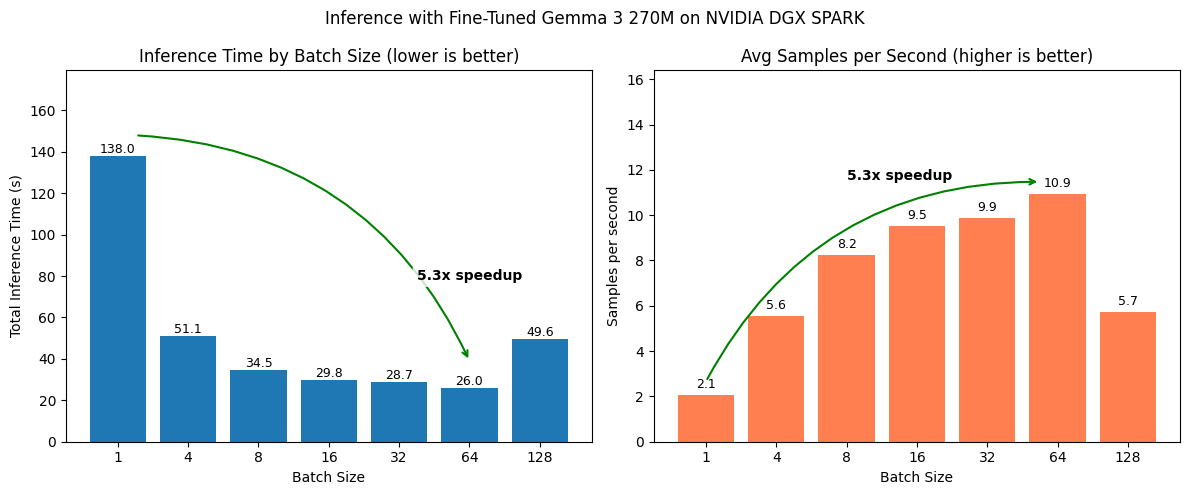

In [50]:
import matplotlib.pyplot as plt

# Set the device name so we can see it on the plot
DEVICE_NAME = "NVIDIA DGX SPARK"

# Extract constant variables
total_samples = len(test_dataset)
all_inference_times = [all_outputs_keydataset[key]["total_time"] for key in all_outputs_keydataset.keys()]
all_samples_per_second = [total_samples / inference_time for inference_time in all_inference_times]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# LEFT PLOT
# Total inference time per batch size
ax1.bar([str(batch_size) for batch_size in BATCH_SIZES_TO_TEST], all_inference_times)
ax1.set_xlabel("Batch Size")
ax1.set_ylabel("Total Inference Time (s)")
ax1.set_title("Inference Time by Batch Size (lower is better)")
ax1.set_ylim(0, max(all_inference_times) * 1.3) # Increase headroom for text

# Add text to each column
for i, inference_time in enumerate(all_inference_times):
    ax1.text(i, inference_time + 1.5, f"{inference_time:.1f}", ha="center", fontsize=9)

# Add arrow to show speedup
# First let's get start (slowest) and end (fastest)
start_val_inference_time = max(all_inference_times)
end_val_inference_time = min(all_inference_times)
start_idx_inference_time = all_inference_times.index(start_val_inference_time)
end_idx_inference_time = all_inference_times.index(end_val_inference_time)

# Measure speedup
speedup_inference_time = start_val_inference_time / end_val_inference_time

# Draw the arrow from start (slowest) to end (fastest)
ax1.annotate("",
             xy=(end_idx_inference_time, end_val_inference_time + (0.5 * end_val_inference_time)), # Add a smaller buffer
             xytext=(start_idx_inference_time + 0.25, start_val_inference_time + 10),
             arrowprops=dict(arrowstyle="->", color="green", lw=1.5, connectionstyle="arc3,rad=-0.3"))

# Add text to arrow at the midpoint
mid_x_inference_time = ((start_idx_inference_time + end_idx_inference_time) / 2) + 1.75
text_y_inference_time = max(start_val_inference_time, end_val_inference_time) + (max(all_inference_times) * 0.1) - 75

ax1.text(x=mid_x_inference_time,
         y=text_y_inference_time,
         s=f"{speedup_inference_time:.1f}x speedup",
         va="bottom",
         fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

# RIGHT PLOT
# Samples per second
ax2.bar([str(batch_size) for batch_size in BATCH_SIZES_TO_TEST], all_samples_per_second, color="coral")
ax2.set_xlabel("Batch Size")
ax2.set_ylabel("Samples per second")
ax2.set_title("Avg Samples per Second (higher is better)")
ax2.set_ylim(0, max(all_samples_per_second) * 1.5) # Increase headroom for text

# Add text to each column
for i, samples_per_second in enumerate(all_samples_per_second):
    ax2.text(i, samples_per_second + 0.3, f"{samples_per_second:.1f}", ha="center", fontsize=9)

# Add arrow for right plot improvements
start_val_samples = min(all_samples_per_second)
end_val_samples = max(all_samples_per_second)
start_idx_samples = all_samples_per_second.index(start_val_samples)
end_idx_samples = all_samples_per_second.index(end_val_samples)

# Measure speedup
speedup_samples_per_second = round(end_val_samples / start_val_samples, 2)

# Draw the arrow from start (slowest) to end (fastest)
ax2.annotate("",
             xy=(end_idx_samples-(0.05 * end_idx_samples), end_val_samples + (0.05 * end_val_samples)),
             xytext=(start_idx_samples, start_val_samples + 0.6),
             arrowprops=dict(arrowstyle="->", color="green", lw=1.5, connectionstyle="arc3,rad=-0.3"))

# Place text at midpoint
mid_x_samples = ((start_idx_samples + end_idx_samples) / 2)
text_y_samples = (max(start_val_samples, end_val_samples) + (max(all_samples_per_second) * 0.1)) * 0.95

ax2.text(x=mid_x_samples-0.5, 
         y=text_y_samples,
         s=f"{speedup_samples_per_second:.1f}x speedup",
         va="bottom",
         fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

# Create a super title
plt.suptitle(f"Inference with Fine-Tuned Gemma 3 270M on {DEVICE_NAME}")
plt.tight_layout()

# Optional: Save the figure to file
# plt.savefig("transformers_llm_batched_inference_benchmark.png", dpi=150)

plt.show()

Those are some nice looking plots!

We can clearly see how batching significantly speeds up inference whilst retaining the same quality of outputs.

### Calculating how many samples we could process per day

One of the main reasons we've implemented batched inference was to increase inference speed.

Because we could use our model to filter a large image dataset for food and drink items.

Now how might this work in practice? How many samples could our model evaluate per day?

Let's write some code to calculate samples per hour as well as samples per day.

In [51]:
# Evaluate how many samples we could process per day
seconds_in_an_hour = 3600

min_samples_per_second = round(min(all_samples_per_second), 2)
max_samples_per_second = round(max(all_samples_per_second), 2)

min_samples_per_hour = seconds_in_an_hour * min_samples_per_second
min_samples_per_day = (seconds_in_an_hour * 24) * min_samples_per_second

max_samples_per_hour = seconds_in_an_hour * max_samples_per_second
max_samples_per_day = (seconds_in_an_hour * 24) * max_samples_per_second

print(f'[INFO] At a minimum speed of {min_samples_per_second:,} samples per second, this means we could process:')
print(f'\t{min_samples_per_hour:,} samples per hour')
print(f'\t{min_samples_per_day:,} samples per day\n')

print(f'[INFO] At a max speed of {max_samples_per_second:,} samples per second, this means we could process:')
print(f'\t{max_samples_per_hour:,} samples per hour')
print(f'\t{max_samples_per_day:,} samples per day')

[INFO] At a minimum speed of 2.06 samples per second, this means we could process:
	7,416.0 samples per hour
	177,984.0 samples per day

[INFO] At a max speed of 10.93 samples per second, this means we could process:
	39,348.0 samples per hour
	944,352.0 samples per day


Excellent, that's exactly what we were looking for.

Batching takes our samples per day close to a total of 1 million.

This means we could filter quite a large dataset in a couple of days or so.

## Extensions

We've seen a significant speedup after increasing the batch size we pass to our model.

Could we make things even faster?

Or how might we evaluate our model outputs even further? For example, on the actual food and drink items it output rather than our current sequence matching implementation.

And right now, our setup currently works for ~300 test samples. But how might we make this a bit more reliable for a large dataset of ~1M samples? Perhaps we would introduce incremental saving and auto-resuming. For example, every 10,000 samples we save a checkpoint and if we run into an error have to restart, our pipeline (optionally) resumes from where it left off. A good exercise would be to try and implement this checkpointing and resumption workflow.

The following two notebooks explore how we might improve our inference speed even further with an inference engine call vLLM as well as how we might dive a little deeper into evaluating our model's generated outputs compared to the ground truth:

* [**LLM structured data extraction evaluation**](https://www.learnhuggingface.com/notebooks/hugging_face_llm_structured_data_extraction_evals) - In this notebook we evaluated our model's output after fine-tuning by manually inspecting samples. And so far this *looks* good. However, in practice or a production setting, you'll likely want to evaluate your models outputs in a more structured way. This notebook focuses on doing just that. Validating our model's output structure as well as applying metrics to actual extraction values compared to the ground truth. Having these specific insights we can plan out how to improve our model's performance in the future.
* [**Speeding up batched inference with vLLM**](https://www.learnhuggingface.com/notebooks/hugging_face_llm_inference_with_vllm) - If you want to step things up even further with faster inference, you'll likely want to use a dedicated inference engine such as vLLM. Because vLLM is designed for fast inference, you'll often see significant speed increases compared to using native Hugging Face `transformers`.

In [ ]:
# UPTOHERE: 
# Done:
# Go back through code, make sure it works ✅
# Add headings ✅
# Clean up code + explanations ✅
# Start to explain what we're doing at each stage ✅

# Next:
# Clean up TK's
    # 15 April 2026, TK Count - 14
    # 15 April 2026, TK Count - 1 (image)
# Add images where necessary
    # Header image
# Create slides
# Prepare for recording  